# Exploratory data analysis: Bharat Delivery ETA

Dataset: `taxis.csv` from `mwaskom/seaborn-data`, a sample of NYC TLC trip records (see `DATASET.md`
for provenance and what is *not verified*). Every number below is computed by the cell that prints it.
Observations are printed by code, not typed by hand.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
from src import config
from src.data import load_raw, validate_raw
from src.preprocessing import add_target, clean
plt.rcParams.update({'figure.figsize': (7, 4), 'axes.grid': True, 'grid.alpha': .3})
raw = load_raw()           # verifies the pinned SHA-256
df = add_target(raw)
T = config.TARGET

## 1. Shape, types, validation

In [2]:
print('shape:', raw.shape)
print(raw.dtypes.to_string())
import json; print(json.dumps(validate_raw(raw), indent=2))

shape: (6433, 14)
pickup                 str
dropoff                str
passengers           int64
distance           float64
fare               float64
tip                float64
tolls              float64
total              float64
color                  str
payment                str
pickup_zone            str
dropoff_zone           str
pickup_borough         str
dropoff_borough        str
{
  "n_rows": 6433,
  "n_exact_duplicate_rows": 0,
  "n_dropoff_not_after_pickup": 6,
  "n_duration_over_max": 0,
  "n_passengers_out_of_range": 0,
  "missing_values": {
    "payment": 44,
    "pickup_zone": 26,
    "dropoff_zone": 45,
    "pickup_borough": 26,
    "dropoff_borough": 45
  },
  "pickup_min": "2019-02-28 23:29:03",
  "pickup_max": "2019-03-31 23:43:45"
}


## 2. Missing values and duplicates

In [3]:
miss = raw.isna().sum(); miss = miss[miss > 0]
print((pd.DataFrame({'n_missing': miss, 'pct': (miss / len(raw) * 100).round(2)})).to_string())
print('exact duplicate rows:', raw.duplicated().sum())
print('rows with missing pickup_zone but present borough:', (raw.pickup_zone.isna() & raw.pickup_borough.notna()).sum())
print('missing zone <=> missing borough (pickup):', ((raw.pickup_zone.isna()) == (raw.pickup_borough.isna())).all())
print('missing payment rows: mean fare', raw[raw.payment.isna()].fare.mean().round(2), 'vs others', raw[raw.payment.notna()].fare.mean().round(2))

                 n_missing   pct
payment                 44  0.68
pickup_zone             26  0.40
dropoff_zone            45  0.70
pickup_borough          26  0.40
dropoff_borough         45  0.70
exact duplicate rows: 0
rows with missing pickup_zone but present borough: 0
missing zone <=> missing borough (pickup): True
missing payment rows: mean fare 11.99 vs others 13.1


## 3. Target: duration in minutes = (dropoff - pickup)

count    6433.00
mean       14.35
std        11.64
min         0.00
1%          0.79
5%          2.93
25%         6.50
50%        10.90
75%        18.52
95%        38.17
99%        57.60
max       107.67
skew: 2.0


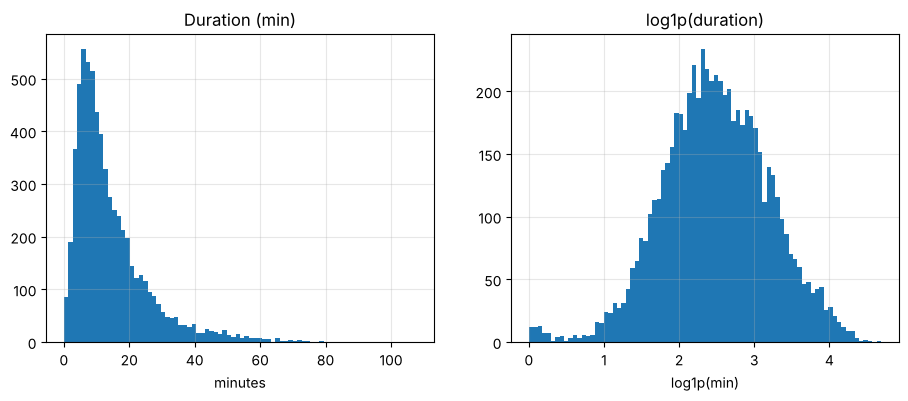

In [4]:
print(df[T].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2).to_string())
print('skew:', round(df[T].skew(), 2))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df[T], bins=80); ax[0].set(title='Duration (min)', xlabel='minutes')
ax[1].hist(np.log1p(df[T]), bins=80); ax[1].set(title='log1p(duration)', xlabel='log1p(min)')
plt.show()

## 4. Outliers and suspicious records

In [5]:
q1, q3 = df[T].quantile([.25, .75]); iqr = q3 - q1; hi = q3 + 1.5 * iqr
print(f'IQR rule upper fence: {hi:.1f} min; trips above: {(df[T] > hi).sum()} ({(df[T] > hi).mean()*100:.1f}%)')
print('duration <= 0:', (df[T] <= 0).sum(), '| duration < 1 min:', (df[T] < 1).sum(), '| > 180 min:', (df[T] > 180).sum())
print('distance == 0:', (df.distance == 0).sum(), '| of which duration > 5 min:', ((df.distance == 0) & (df[T] > 5)).sum())
df['speed_mph'] = df.distance / (df[T] / 60).replace(0, np.nan)
print(df.speed_mph.describe(percentiles=[.01, .5, .99]).round(1).to_string())
print('implied speed > 60 mph:', (df.speed_mph > 60).sum())
print('passengers == 0:', (df.passengers == 0).sum())
print('\nSample suspicious rows (duration<=0 or speed>60):')
print(df[(df[T] <= 0) | (df.speed_mph > 60)][['pickup', 'dropoff', 'distance', 'fare', T, 'speed_mph']].head(10).to_string())

IQR rule upper fence: 36.5 min; trips above: 358 (5.6%)
duration <= 0: 6 | duration < 1 min: 72 | > 180 min: 0
distance == 0: 51 | of which duration > 5 min: 4
count    6427.0
mean       13.1
std        68.0
min         0.0
1%          2.6
50%        10.0
99%        34.0
max      4834.3
implied speed > 60 mph: 11
passengers == 0: 96

Sample suspicious rows (duration<=0 or speed>60):
                  pickup             dropoff  distance   fare  duration_min    speed_mph
400  2019-03-09 17:26:02 2019-03-09 17:26:10      0.90   2.50      0.133333   405.000000
491  2019-03-07 07:11:33 2019-03-07 07:11:39      1.60   2.50      0.100000   960.000000
770  2019-03-02 03:16:59 2019-03-02 03:17:06      9.40   2.50      0.116667  4834.285714
1690 2019-03-22 06:24:14 2019-03-22 06:24:14      0.00  72.00      0.000000          NaN
2387 2019-03-28 15:58:52 2019-03-28 15:59:25      1.80  69.06      0.550000   196.363636
3241 2019-03-24 17:19:27 2019-03-24 17:19:29      0.34  65.00      0.033333   61

## 5. Numerical feature distributions

       passengers  distance     fare      tip    tolls    total
count     6433.00   6433.00  6433.00  6433.00  6433.00  6433.00
mean         1.54      3.02    13.09     1.98     0.33    18.52
std          1.20      3.83    11.55     2.45     1.42    13.82
min          0.00      0.00     1.00     0.00     0.00     1.30
25%          1.00      0.98     6.50     0.00     0.00    10.80
50%          1.00      1.64     9.50     1.70     0.00    14.16
75%          2.00      3.21    15.00     2.80     0.00    20.30
max          6.00     36.70   150.00    33.20    24.02   174.82


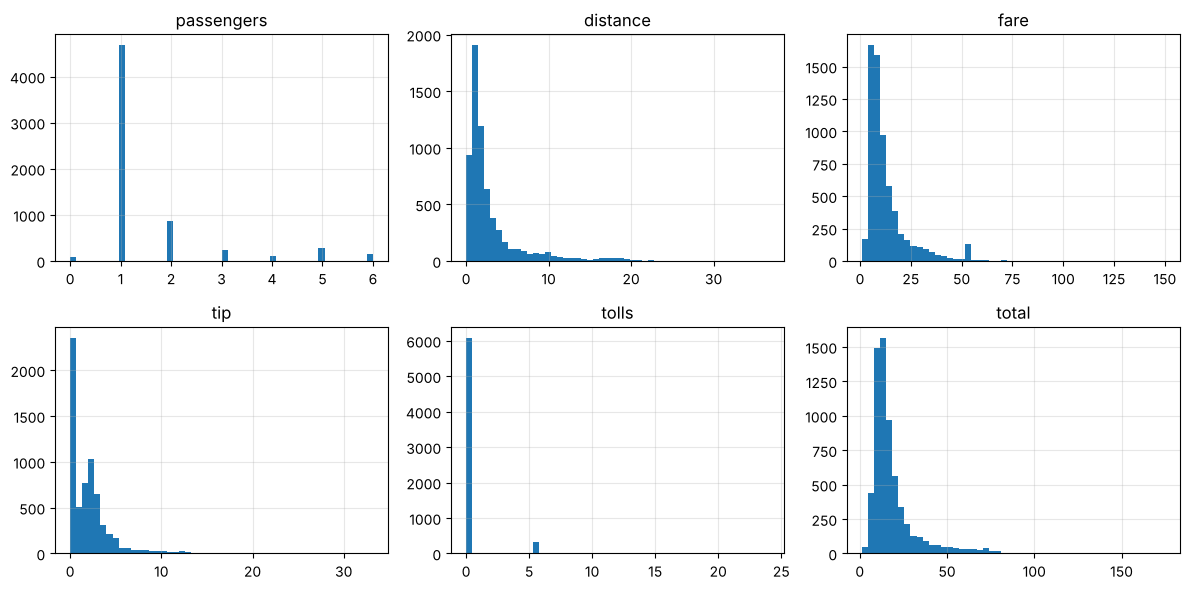

In [6]:
num = ['passengers', 'distance', 'fare', 'tip', 'tolls', 'total']
print(df[num].describe().round(2).to_string())
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for a, c in zip(axes.ravel(), num):
    a.hist(df[c], bins=50); a.set_title(c)
plt.tight_layout(); plt.show()

## 6. Categorical frequencies

In [7]:
for c in ['color', 'payment', 'pickup_borough', 'dropoff_borough']:
    print(df[c].value_counts(dropna=False).to_string(), '\n')
print('distinct pickup zones:', df.pickup_zone.nunique(), '| dropoff zones:', df.dropoff_zone.nunique())
print(df.pickup_zone.value_counts().head(10).to_string())
pairs = df.dropna(subset=['pickup_zone','dropoff_zone']).groupby(['pickup_zone','dropoff_zone']).size()
print('\ndistinct zone pairs:', len(pairs), '| pairs seen exactly once:', (pairs == 1).sum(), f'({(pairs == 1).mean()*100:.0f}%)')

color
yellow    5451
green      982 

payment
credit card    4577
cash           1812
NaN              44 

pickup_borough
Manhattan    5268
Queens        657
Brooklyn      383
Bronx          99
NaN            26 

dropoff_borough
Manhattan        5206
Queens            542
Brooklyn          501
Bronx             137
NaN                45
Staten Island       2 

distinct pickup zones: 194 | dropoff zones: 203
pickup_zone
Midtown Center                  230
Upper East Side South           211
Penn Station/Madison Sq West    210
Clinton East                    208
Midtown East                    198
Upper East Side North           186
Times Sq/Theatre District       184
Union Sq                        180
Lincoln Square East             177
Murray Hill                     162

distinct zone pairs: 2737 | pairs seen exactly once: 1544 (56%)


## 7. Correlation (Pearson, numeric columns) — includes post-trip columns for diagnosis only

In [8]:
c = df[num + [T]].corr().round(2)
print(c[T].sort_values(ascending=False).to_string())
print('\nNOTE: distance, fare, tip, tolls and total are only known after the trip and are NOT model inputs.')

duration_min    1.00
fare            0.85
distance        0.82
total           0.82
tolls           0.46
tip             0.39
passengers     -0.00

NOTE: distance, fare, tip, tolls and total are only known after the trip and are NOT model inputs.


## 8. Target vs. major features

        count   mean  median
color                       
green     982  15.62   10.90
yellow   5451  14.12   10.92
                count   mean  median
pickup_borough                      
Bronx              99  24.50   20.63
Brooklyn          383  18.93   14.27
Manhattan        5268  12.79   10.22
Queens            657  22.89   18.72
            count   mean  median
passengers                      
0              96  15.05   11.52
1            4678  14.40   10.83
2             876  14.05   10.89
3             243  14.26   11.07
4             110  15.16   12.52
5             277  13.78   10.85
6             153  14.79   11.35


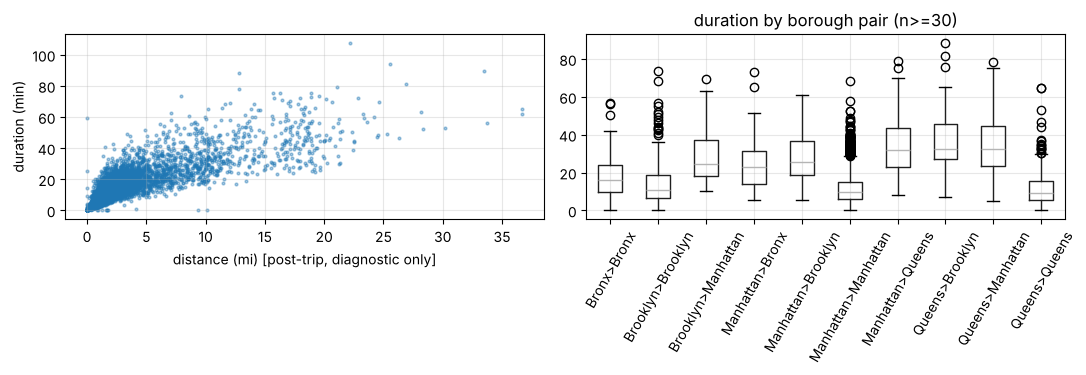

In [9]:
print(df.groupby('color')[T].agg(['count', 'mean', 'median']).round(2).to_string())
print(df.groupby('pickup_borough')[T].agg(['count', 'mean', 'median']).round(2).to_string())
print(df.groupby('passengers')[T].agg(['count', 'mean', 'median']).round(2).to_string())
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(df.distance, df[T], s=4, alpha=.4); ax[0].set(xlabel='distance (mi) [post-trip, diagnostic only]', ylabel='duration (min)')
bp = df.dropna(subset=['pickup_borough', 'dropoff_borough']).assign(pair=lambda d: d.pickup_borough + '>' + d.dropoff_borough)
top = bp.pair.value_counts().loc[lambda s: s >= 30].index
bp[bp.pair.isin(top)].boxplot(column=T, by='pair', ax=ax[1], rot=60); ax[1].set(title='duration by borough pair (n>=30)', xlabel='')
plt.suptitle(''); plt.tight_layout(); plt.show()

## 9. Time patterns

pickup range: 2019-02-28 23:29:03 -> 2019-03-31 23:43:45 | distinct dates: 32
rows dated before 2019-03-01: 1


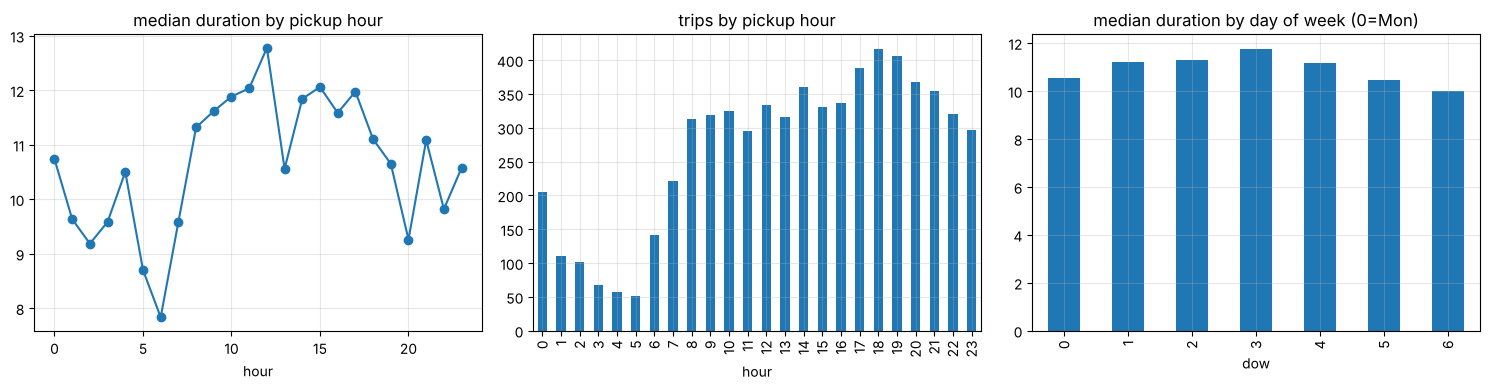

     count  median
dow               
0      708   10.54
1      825   11.22
2      966   11.29
3      905   11.77
4     1115   11.15
5     1046   10.47
6      868    9.98


In [10]:
df['hour'] = df.pickup.dt.hour; df['dow'] = df.pickup.dt.dayofweek; df['date'] = df.pickup.dt.date
print('pickup range:', df.pickup.min(), '->', df.pickup.max(), '| distinct dates:', df.date.nunique())
print('rows dated before 2019-03-01:', (df.pickup < '2019-03-01').sum())
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df.groupby('hour')[T].median().plot(ax=ax[0], marker='o', title='median duration by pickup hour')
df.groupby('hour').size().plot.bar(ax=ax[1], title='trips by pickup hour')
df.groupby('dow')[T].median().plot.bar(ax=ax[2], title='median duration by day of week (0=Mon)')
plt.tight_layout(); plt.show()
print(df.groupby('dow')[T].agg(['count', 'median']).round(2).to_string())

## 10. Geographic view (zone names only; the file has no coordinates)

In [11]:
z = df.dropna(subset=['pickup_zone']).groupby('pickup_zone')[T].agg(['count', 'median']).query('count >= 30').sort_values('median')
print('pickup zones with >=30 trips:', len(z)); print(z.head(5).round(1).to_string()); print(z.tail(5).round(1).to_string())
print('\nshare of trips staying within one borough:', round((df.pickup_borough == df.dropoff_borough).mean() * 100, 1), '%')

pickup zones with >=30 trips: 56
                       count  median
pickup_zone                         
Astoria                   65     6.8
Central Harlem            68     7.7
Morningside Heights       63     7.7
Upper East Side South    211     7.8
Upper East Side North    186     7.9
                          count  median
pickup_zone                            
Washington Heights South     32    14.8
Financial District North     35    14.8
Battery Park City            43    16.4
LaGuardia Airport           146    27.3
JFK Airport                 151    33.9

share of trips staying within one borough: 86.8 %


## 11. Leakage review of every column

In [12]:
review = pd.DataFrame([
 ('pickup', 'start timestamp', 'yes', 'INPUT (time features)'),
 ('dropoff', 'end timestamp', 'NO', 'REJECTED: defines the target'),
 ('passengers', 'driver-entered count', 'yes', 'INPUT'),
 ('distance', 'metered trip distance', 'NO', 'REJECTED: measured over the completed trip'),
 ('fare', 'metered fare', 'NO', 'REJECTED: function of distance and time travelled'),
 ('tip', 'tip', 'NO', 'REJECTED: paid at trip end'),
 ('tolls', 'tolls', 'NO', 'REJECTED: depends on route taken'),
 ('total', 'sum of charges', 'NO', 'REJECTED: post-trip'),
 ('color', 'taxi type', 'yes', 'INPUT'),
 ('payment', 'payment type', 'NO', 'REJECTED: recorded at trip end'),
 ('pickup_zone', 'start zone', 'yes', 'INPUT'),
 ('dropoff_zone', 'end zone', 'yes*', 'INPUT (*assumes destination is given when requesting an ETA)'),
 ('pickup_borough/dropoff_borough', 'derived from zones', 'yes', 'derived inside the model from zones'),
], columns=['column', 'meaning', 'known at prediction time', 'decision'])
print(review.to_string(index=False))
assert set(config.INPUT_COLUMNS) == {'pickup', 'passengers', 'color', 'pickup_zone', 'dropoff_zone'}

                        column               meaning known at prediction time                                                     decision
                        pickup       start timestamp                      yes                                        INPUT (time features)
                       dropoff         end timestamp                       NO                                 REJECTED: defines the target
                    passengers  driver-entered count                      yes                                                        INPUT
                      distance metered trip distance                       NO                   REJECTED: measured over the completed trip
                          fare          metered fare                       NO            REJECTED: function of distance and time travelled
                           tip                   tip                       NO                                   REJECTED: paid at trip end
                         to

## 12. Data-quality findings and cleaning effect

In [13]:
cleaned, rep = clean(raw)
print(json.dumps(rep, indent=2))
print('target mean/median before cleaning:', df[T].mean().round(3), df[T].median().round(3))
print('target mean/median after  cleaning:', cleaned[T].mean().round(3), cleaned[T].median().round(3))
print('rows kept with duration < 1 min (not excluded):', (cleaned[T] < 1).sum())
print('rows kept with missing zone(s):', cleaned[['pickup_zone', 'dropoff_zone']].isna().any(axis=1).sum())

{
  "n_input": 6433,
  "excluded_duplicates": 0,
  "excluded_invalid_duration": 6,
  "excluded_passengers_out_of_range": 0,
  "n_clean": 6427
}
target mean/median before cleaning: 14.35 10.9
target mean/median after  cleaning: 14.363 10.917
rows kept with duration < 1 min (not excluded): 66
rows kept with missing zone(s): 44
